<a href="https://colab.research.google.com/github/sanjay-0607/Machine-Learning/blob/main/VGG16_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import os

In [2]:
zip_file_path='/content/rat_cat_dog.zip'
extract_dir= '.'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.path.abspath(extract_dir))


/content


In [3]:
from pathlib import Path

In [4]:
p=Path(extract_dir)

In [5]:
images=[]
for f in p.rglob('*'):
  # if f.is_file():
    print(f)
    images.append(f)
    # print(str(f.resolve()))

.config
rat_cat_dog.zip
rat_cat_dog
sample_data
.config/.last_survey_prompt.yaml
.config/logs
.config/.last_update_check.json
.config/default_configs.db
.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
.config/.last_opt_in_prompt.yaml
.config/active_config
.config/config_sentinel
.config/configurations
.config/gce
rat_cat_dog/cat2.jpg
rat_cat_dog/dog.jpg
rat_cat_dog/dog1.jpg
rat_cat_dog/labels.csv
rat_cat_dog/cat.jpg
rat_cat_dog/dog2.jpg
rat_cat_dog/cat1.jpg
rat_cat_dog/rat1.jpg
rat_cat_dog/rat.jpg
rat_cat_dog/rat2.jpg
sample_data/anscombe.json
sample_data/README.md
sample_data/mnist_train_small.csv
sample_data/california_housing_test.csv
sample_data/california_housing_train.csv
sample_data/mnist_test.csv
.config/logs/2026.04.16
.config/configurations/config_default
.config/logs/2026.04.16/13.27.28.140888.log
.config/logs/2026.04.16/13.28.06.952902.log
.config/logs/2026.04.16/13.28.22.950479.log
.config/logs/2026.04.16/13.27.53.684484.log
.config/logs/2026.04.16/1

In [6]:
image_dir = Path("rat_cat_dog")

In [7]:
st="rat.jpg"

In [8]:
print(images)

[PosixPath('.config'), PosixPath('rat_cat_dog.zip'), PosixPath('rat_cat_dog'), PosixPath('sample_data'), PosixPath('.config/.last_survey_prompt.yaml'), PosixPath('.config/logs'), PosixPath('.config/.last_update_check.json'), PosixPath('.config/default_configs.db'), PosixPath('.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db'), PosixPath('.config/.last_opt_in_prompt.yaml'), PosixPath('.config/active_config'), PosixPath('.config/config_sentinel'), PosixPath('.config/configurations'), PosixPath('.config/gce'), PosixPath('rat_cat_dog/cat2.jpg'), PosixPath('rat_cat_dog/dog.jpg'), PosixPath('rat_cat_dog/dog1.jpg'), PosixPath('rat_cat_dog/labels.csv'), PosixPath('rat_cat_dog/cat.jpg'), PosixPath('rat_cat_dog/dog2.jpg'), PosixPath('rat_cat_dog/cat1.jpg'), PosixPath('rat_cat_dog/rat1.jpg'), PosixPath('rat_cat_dog/rat.jpg'), PosixPath('rat_cat_dog/rat2.jpg'), PosixPath('sample_data/anscombe.json'), PosixPath('sample_data/README.md'), PosixPath('sample_data/mnist_train_small

In [9]:
print(type(images))
print(type(images[0]))
print(images[0])

<class 'list'>
<class 'pathlib.PosixPath'>
.config


In [10]:
from pathlib import Path

image_dir = Path("rat_cat_dog")

images = [p for p in image_dir.rglob("*") if p.suffix.lower() in [".jpg", ".png", ".jpeg", ".webp"]]


In [11]:
print(images[:5])

[PosixPath('rat_cat_dog/cat2.jpg'), PosixPath('rat_cat_dog/dog.jpg'), PosixPath('rat_cat_dog/dog1.jpg'), PosixPath('rat_cat_dog/cat.jpg'), PosixPath('rat_cat_dog/dog2.jpg')]


In [12]:
print(len(images))

9


In [13]:
for img in images:
    print(img)

rat_cat_dog/cat2.jpg
rat_cat_dog/dog.jpg
rat_cat_dog/dog1.jpg
rat_cat_dog/cat.jpg
rat_cat_dog/dog2.jpg
rat_cat_dog/cat1.jpg
rat_cat_dog/rat1.jpg
rat_cat_dog/rat.jpg
rat_cat_dog/rat2.jpg


In [14]:
y = []

In [15]:
for st in images:
    s = st.name.lower()   # VERY IMPORTANT

    if 'rat' in s:
        y.append(0)
    elif 'dog' in s:
        y.append(1)
    else:
        y.append(2)

In [16]:
for st in images:
    s = st.name.lower()
    print(s, '->', 'rat' in s)

cat2.jpg -> False
dog.jpg -> False
dog1.jpg -> False
cat.jpg -> False
dog2.jpg -> False
cat1.jpg -> False
rat1.jpg -> True
rat.jpg -> True
rat2.jpg -> True


In [17]:
print(y)

[2, 1, 1, 2, 1, 2, 0, 0, 0]


In [18]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

In [19]:
label_map = {
    'cat': 0,
    'dog': 1,
    'rat': 2
}


In [20]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [21]:
X = []
y = []

In [22]:

X = []
y = []

for path in images:
    img = Image.open(path).convert("RGB")
    img = transform(img)
    X.append(img)

    name = path.name.lower()

    for key in label_map:
        if key in name:
            y.append(label_map[key])
            break

In [23]:
X = torch.stack(X)
y = torch.tensor(y)

In [24]:
model = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 130MB/s]


In [25]:
model.classifier[6] = nn.Linear(4096, 3)  # 3 classes

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [27]:

epochs = 5

for epoch in range(epochs):
    outputs = model(X)
    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")


Epoch 1, Loss: 1.1858614683151245
Epoch 2, Loss: 1.1733192205429077
Epoch 3, Loss: 2.0355641841888428
Epoch 4, Loss: 1.3102995157241821
Epoch 5, Loss: 1.0576205253601074


In [28]:
import cv2

In [33]:
ar = cv2.imread('/content/rat_cat_dog/cat/dog.jpg')

In [34]:
if ar is not None:
    ar.shape
else:
    print("Error: 'ar' is None. Image loading failed in the previous cell.")

Error: 'ar' is None. Image loading failed in the previous cell.


In [37]:
ar = cv2.imread("rat_cat_dog/cat/cat1.jpg")

In [54]:
import cv2

ar = cv2.imread("rat_cat_dog/cat1.jpg")

if ar is None:
    print(" Not loaded")
else:
    print("Loaded successfully")

Loaded successfully


In [55]:
grar = cv2.cvtColor(ar, cv2.COLOR_BGR2GRAY)
rszar = cv2.resize(grar, (28,28))
far = rszar.reshape(1,1,28,28)

In [56]:
far

array([[[[ 31,  26,  22,  20,  16,  15,  14,  12,   8,   7,   6,   6,
            6,   6,   6,   6,   5,   5,   4,   4,   4,   4,   4,   4,
            4,   4,   4,   3],
         [ 61,  58,  54,  52,  50,  47,  44,  42,  39,  33,  25,  19,
           16,  14,  12,  11,  10,   9,   7,   7,   7,   7,   7,   7,
            6,   5,   5,   4],
         [ 79,  78,  72,  69,  67,  70,  72,  72,  69,  66,  58,  49,
           46,  45,  42,  40,  38,  35,  33,  27,  24,  19,  16,  11,
            9,   8,   7,   7],
         [ 95,  91,  85,  79,  78,  82,  90,  92,  91,  90,  84,  79,
           78,  82,  80,  77,  77,  81,  97,  71,  66,  62,  59,  53,
           50,  43,  39,  33],
         [110, 105,  99,  94,  92,  96, 101, 107, 111, 119, 109, 116,
          123, 127, 112, 107, 201, 165,  98, 107,  93,  93,  89,  85,
           82,  78,  73,  70],
         [121, 118, 112, 113, 123, 122, 122, 134, 144, 145, 150, 142,
          140, 145, 139, 162, 133, 138,  91, 122, 113, 106, 104, 100,
     

In [57]:
import matplotlib.pyplot as plt

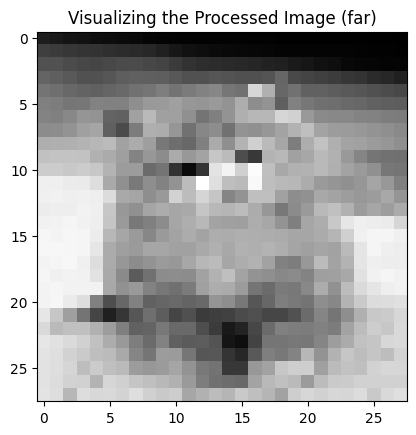

In [58]:
plt.imshow(far.squeeze(), cmap='gray')
plt.title('Visualizing the Processed Image (far)')
plt.show()

In [59]:
fimg = torch.from_numpy(far).float()
print(f"Shape of fimg before model call: {fimg.shape}")

Shape of fimg before model call: torch.Size([1, 1, 28, 28])


In [60]:
import torch.nn.functional as F
# fimg is currently torch.Size([1, 1, 28, 28]) and values in [0, 255]
# 1. Scale pixel values to [0.0, 1.0]
fimg_scaled = fimg / 255.0
# 2. Replicate the single channel to three channels
fimg_3channel = fimg_scaled.repeat(1, 3, 1, 1) # Shape becomes [1, 3, 28, 28]
# 3. Resize the image to 224x224
fimg_final = F.interpolate(fimg_3channel, size=(224, 224), mode='bilinear', align_corners=False)
# Pass the processed image to the model
model(fimg_final)


tensor([[-0.7680, -0.3580,  0.0048]], grad_fn=<AddmmBackward0>)

In [61]:
sfx=torch.softmax(model(fimg_final),dim=1)

In [62]:
torch.argmax(sfx,dim=1)

tensor([1])